In [25]:
# pip install -U kaleido

In [26]:
import pandas as pd
import os
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report
from sklearn.inspection import permutation_importance

In [27]:
os.getcwd()

'/Users/maegbugpeulo/Desktop/pangmini/Data_analysis/Telco Customer Churn'

### 데이터 로드

In [28]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

## 데이터 확인

In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- 사용자 ID
- 성별
- 시니어 유무
- 배우자 유무
- 부양가족 유무
- 구독 기간
- 폰 서비스 사용 유무
- 멀티플 라인
- 인터넷 서비스 사용 유무
- 온라인 보안서비스 사용 유무
- 온라인 백업 서비스 사용 유무
- 기술지원 사용 유무
- 스트리밍 티비 사용 유무
- 스트리밍 영황 사용 유무
- 계약 유형(1달, 1년, 2년)
- 온라인 청구서 사용 유무
- 지불 방법
- 매월 청구 요금
- 총 청구 요금
- 이탈 유무

결측치 없음!

In [31]:
df.shape

(7043, 21)

In [32]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [33]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

### 결측치 시각화

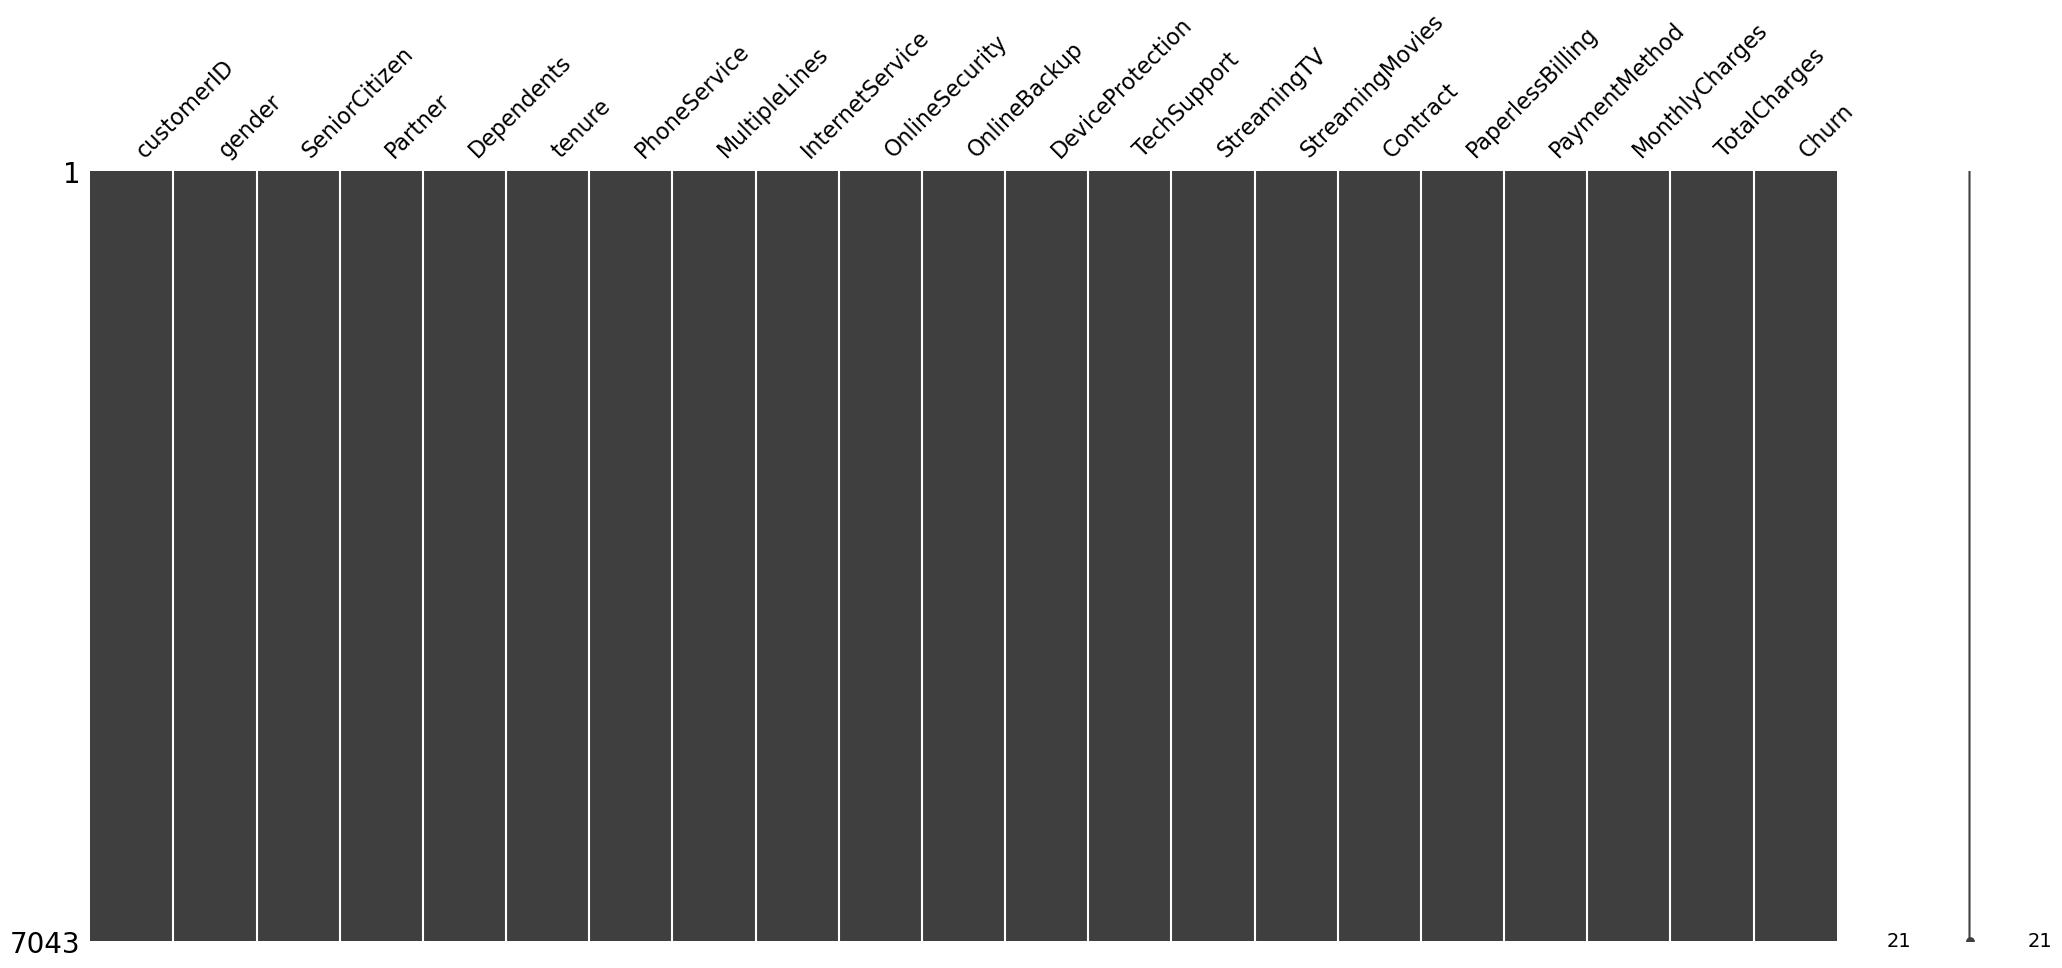

In [34]:
msno.matrix(df);

In [35]:
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [37]:
df[df['tenure'] == 0][['tenure', 'Churn', 'TotalCharges', 'MonthlyCharges']]

,tenure,Churn,TotalCharges,MonthlyCharges
488,0,No,,52.55
753,0,No,,20.25
936,0,No,,80.85
1082,0,No,,25.75
1340,0,No,,56.05
3331,0,No,,19.85
3826,0,No,,25.35
4380,0,No,,20.00
5218,0,No,,19.70
6670,0,No,,73.35


In [38]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

계약 유지기간이 0인 행은 삭제
이유 : 계약 첫 달로 판단 되고, 11개의 행밖에 되지 않아서 정확도를 낮출 수 있다고 판단.

In [39]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [40]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [41]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
df['SeniorCitizen'].unique()

array([0, 1])

조금더 직관적으로 보기위해 0을 no, 1을 yes에 매핑

In [43]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 데이터 확인 요약

- 데이터에 결측치는 존재하지 않음.
- 계약 한지 1달이 되지 않은 고객은 전체 고객중 11명, 이들은 데이터 분석시 오류를 초래할 수 있을 것으로 판단되어 삭제 진행.
- SeniorCitizen은 yes,no로 매핑하여 직관적으로 수정

## 시각화

#### 성별과 이탈 분포 시각화

In [44]:
g_labels = ['Male', 'Female']
c_labels = ['No', 'Yes']
# 파이차트 만들기
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels, values=df['gender'].value_counts(), name="Gender"),
              1, 1)
fig.add_trace(go.Pie(labels=c_labels, values=df['Churn'].value_counts(), name="Churn"),
              1, 2)

# 도넛형 만들기
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)

fig.update_layout(
    title_text="Gender and Churn Distributions",
    # 가운데 주석달기
    annotations=[dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False),
                 dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)]
)
fig.show()

전체 데이터중 남성(50.5%)과 여성(49.5)의 비율과, 전체 데이터 중 이탈 고객(26.6) 비율 파이차트 시각화

In [45]:
df["Churn"][df["Churn"]=="No"].groupby(by=df["gender"]).count()

gender
Female    2544
Male      2619
Name: Churn, dtype: int64

In [46]:
df["Churn"][df["Churn"]=="Yes"].groupby(by=df["gender"]).count()

gender
Female    939
Male      930
Name: Churn, dtype: int64

In [47]:
yes_gender = (df.loc[df['Churn'] == 'Yes', 'gender']
   .value_counts(normalize=True)
   .mul(100)
   .round(1))

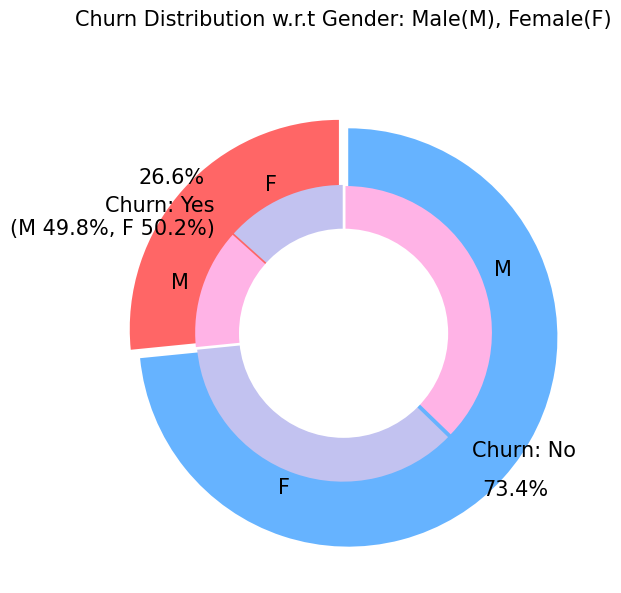

In [48]:
plt.figure(figsize=(6, 6))
f_pct = yes_gender.get('Female', 0.0)
m_pct = yes_gender.get('Male', 0.0)

# 2) 바깥 파이 라벨에 붙이기
labels = [f"Churn: Yes\n(M {m_pct}%, F {f_pct}%)", "Churn: No"]
# labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["F","M","F","M"]
sizes_gender = [939,930 , 2544,2619]
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3) 
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
# 구멍뚫기
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, y=1.1)

# show plot 
 
plt.axis('equal')
plt.tight_layout()
plt.show()

이탈 고객중 남성(49.8%), 여성(50.2%)로 전체 남녀 성비와 큰 차이가 없음!
따라서, 성비에 따른 고객 이탈 여부는 큰 상관관계를 찾지 못함

In [49]:
fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [50]:
mask_yes = df["Churn"].eq("Yes")

# 비율(0~1)
ratio = df.loc[mask_yes, "Contract"].eq("Month-to-month").mean()
ratio1 = df.loc[mask_yes, "Contract"].eq("One year").mean()
ratio2 = df.loc[mask_yes, "Contract"].eq("Two year").mean()

ratio_pct = ratio * 100
ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
print(ratio_pct)
print(ratio_pct1)
print(ratio_pct2)

88.55002675227395
8.881754949170679
2.568218298555377


한달 단위 계약 고객이 이탈을 선택한 비율(약 88.6%)이 가장 높게 나타남.

In [51]:
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()

구독 고객중 electronic check로 지불하는 비율이 가장 높음.

In [52]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [53]:
mask_yes = df["Churn"].eq("Yes")

# 비율(0~1)
ratio = df.loc[mask_yes, "PaymentMethod"].eq("Electronic check").mean()

ratio_pct = ratio * 100
ratio_pct

np.float64(57.30337078651685)

이탈하지 않은 고객은 지불방법이 고르게 분포한 반면, 이탈 고객중 electronic check지불 방법을 선택한 고객(약 57.3%)이 가장 많은 이탈을 진행함.

In [54]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [55]:
 df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()


InternetService  Churn
DSL              No       992
Fiber optic      No       910
No               No       717
Fiber optic      Yes      633
DSL              Yes      240
No               Yes       57
Name: count, dtype: int64

In [56]:
df[df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       965
Fiber optic      No       889
No               No       690
Fiber optic      Yes      664
DSL              Yes      219
No               Yes       56
Name: count, dtype: int64

In [57]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.show()

In [58]:
service_col = "InternetService"         
services = ["DSL", "Fiber optic", "No"]  

ratio_tbl = (
    df.groupby(["Churn", "gender"])[service_col]
      .value_counts(normalize=True)
      .mul(100)
      .unstack(fill_value=0)
      .reindex(columns=services, fill_value=0)
      .round(1)
)

print(ratio_tbl)

InternetService   DSL  Fiber optic    No
Churn gender                            
No    Female     37.9         34.9  27.1
      Male       37.9         34.7  27.4
Yes   Female     23.3         70.7   6.0
      Male       25.8         68.1   6.1


DSL사용자보다 Fiber optic(광섬유) 가입자의 이탈률이 성별과 관계없이 높게 나타남.

In [59]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [60]:
mask_yes = df["Churn"].eq("Yes")
mask_no = df["Churn"].eq("No")
# 비율(0~1)
ratio1 = df.loc[mask_yes, "Dependents"].eq("No").mean()
ratio2 = df.loc[mask_yes, "Dependents"].eq("Yes").mean()
ratio3 = df.loc[mask_no, "Dependents"].eq("No").mean()
ratio4 = df.loc[mask_no, "Dependents"].eq("Yes").mean()

ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
ratio_pct3 = ratio3 * 100
ratio_pct4 = ratio4 * 100
print('======yes======')
print("No : ",ratio_pct1)
print("Yes : ",ratio_pct2)
print('======no======')
print("No : ",ratio_pct3)
print("Yes : ",ratio_pct4)

======yes======
No :  82.55751738897807
Yes :  17.442482611021937
======no======
No :  65.65950029052875
Yes :  34.34049970947124


부양가족이 없는 고객이 이탈률이 높음. 그러나 이탈하지 않은 고객도 부양가족이 없는 비율이 더 높음.

In [61]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Chrun distribution w.r.t. Partners</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [62]:
mask_yes = df["Churn"].eq("Yes")
mask_no = df["Churn"].eq("No")
# 비율(0~1)
ratio1 = df.loc[mask_yes, "Partner"].eq("No").mean()
ratio2 = df.loc[mask_yes, "Partner"].eq("Yes").mean()
ratio3 = df.loc[mask_no, "Partner"].eq("No").mean()
ratio4 = df.loc[mask_no, "Partner"].eq("Yes").mean()

ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
ratio_pct3 = ratio3 * 100
ratio_pct4 = ratio4 * 100
print('======yes======')
print("No : ",ratio_pct1)
print("Yes : ",ratio_pct2)
print('======no======')
print("No : ",ratio_pct3)
print("Yes : ",ratio_pct4)

======yes======
No :  64.20545746388443
Yes :  35.79454253611557
======no======
No :  47.23997675769901
Yes :  52.76002324230099


파트너가 없는 가입자가 이탈할 확률이 파트너가 있는 가입자보다 더 높게 나타남.

In [63]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Chrun distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [64]:
mask_yes = df["Churn"].eq("Yes")
mask_no = df["Churn"].eq("No")
# 비율(0~1)
ratio1 = df.loc[mask_yes, "SeniorCitizen"].eq("No").mean()
ratio2 = df.loc[mask_yes, "SeniorCitizen"].eq("Yes").mean()
ratio3 = df.loc[mask_no, "SeniorCitizen"].eq("No").mean()
ratio4 = df.loc[mask_no, "SeniorCitizen"].eq("Yes").mean()

ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
ratio_pct3 = ratio3 * 100
ratio_pct4 = ratio4 * 100
print('======yes======')
print("No : ",ratio_pct1)
print("Yes : ",ratio_pct2)
print('======no======')
print("No : ",ratio_pct3)
print("Yes : ",ratio_pct4)

======yes======
No :  74.53183520599251
Yes :  25.468164794007492
======no======
No :  87.10052295177223
Yes :  12.899477048227775


젊은 가입자들이 이탈률이 더 높음. 그러나, 나이가 많은 고객들의 약 25%가 가입을 중단함.

In [65]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [66]:
mask_yes = df["Churn"].eq("Yes")
mask_no = df["Churn"].eq("No")
# 비율(0~1)
ratio1 = df.loc[mask_yes, "OnlineSecurity"].eq("No").mean()
ratio2 = df.loc[mask_yes, "OnlineSecurity"].eq("Yes").mean()
ratio3 = df.loc[mask_yes, "OnlineSecurity"].eq("No internet service").mean()
ratio4 = df.loc[mask_no, "OnlineSecurity"].eq("No").mean()
ratio5 = df.loc[mask_no, "OnlineSecurity"].eq("Yes").mean()
ratio6 = df.loc[mask_no, "OnlineSecurity"].eq("No internet service").mean()

ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
ratio_pct3 = ratio3 * 100
ratio_pct4 = ratio4 * 100
ratio_pct5 = ratio5 * 100
ratio_pct6 = ratio6 * 100
print('======yes======')
print("No : ",ratio_pct1)
print("Yes : ",ratio_pct2)
print("No internet service : ",ratio_pct3)
print('======no======')
print("No : ",ratio_pct4)
print("Yes : ",ratio_pct5)
print("No internet service : ",ratio_pct6)

======yes======
No :  78.1701444622793
Yes :  15.783841626538257
No internet service :  6.046013911182451
======no======
No :  39.434437342630254
Yes :  33.31396474917683
No internet service :  27.25159790819291


온라인 보안서비스를 사용하지 않는 고객이 온라인 보안서비스를 사용하는 고객보다 이탈률이 더 높음.

In [67]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Chrun distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [68]:
mask_yes = df["Churn"].eq("Yes")
mask_no = df["Churn"].eq("No")
# 비율(0~1)
ratio1 = df.loc[mask_yes, "PaperlessBilling"].eq("No").mean()
ratio2 = df.loc[mask_yes, "PaperlessBilling"].eq("Yes").mean()
ratio3 = df.loc[mask_no, "PaperlessBilling"].eq("No").mean()
ratio4 = df.loc[mask_no, "PaperlessBilling"].eq("Yes").mean()

ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
ratio_pct3 = ratio3 * 100
ratio_pct4 = ratio4 * 100
print('======yes======')
print("No : ",ratio_pct1)
print("Yes : ",ratio_pct2)
print('======no======')
print("No : ",ratio_pct3)
print("Yes : ",ratio_pct4)

======yes======
No :  25.0936329588015
Yes :  74.90636704119851
======no======
No :  46.387759054813095
Yes :  53.612240945186905


디지털 청구서를 사용하는 고객이 디지털 청구서를 사용하지 않는 고객보다 이탈률이 더 높음.

In [69]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Chrun distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [70]:
mask_yes = df["Churn"].eq("Yes")
mask_no = df["Churn"].eq("No")
# 비율(0~1)
ratio1 = df.loc[mask_yes, "TechSupport"].eq("No").mean()
ratio2 = df.loc[mask_yes, "TechSupport"].eq("Yes").mean()
ratio3 = df.loc[mask_yes, "TechSupport"].eq("No internet service").mean()
ratio4 = df.loc[mask_no, "TechSupport"].eq("No").mean()
ratio5 = df.loc[mask_no, "TechSupport"].eq("Yes").mean()
ratio6 = df.loc[mask_no, "TechSupport"].eq("No internet service").mean()

ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
ratio_pct3 = ratio3 * 100
ratio_pct4 = ratio4 * 100
ratio_pct5 = ratio5 * 100
ratio_pct6 = ratio6 * 100
print('======yes======')
print("No : ",ratio_pct1)
print("Yes : ",ratio_pct2)
print("No internet service : ",ratio_pct3)
print('======no======')
print("No : ",ratio_pct4)
print("Yes : ",ratio_pct5)
print("No internet service : ",ratio_pct6)

======yes======
No :  77.36757624398074
Yes :  16.586409844836812
No internet service :  6.046013911182451
======no======
No :  39.240751501065276
Yes :  33.50765059074182
No internet service :  27.25159790819291


기술지원을 받지 않는 고객이 이탈률이 더 높음

In [71]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Chrun distribution w.r.t. Phone Service</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [72]:
mask_yes = df["Churn"].eq("Yes")
mask_no = df["Churn"].eq("No")
# 비율(0~1)
ratio1 = df.loc[mask_yes, "PhoneService"].eq("No").mean()
ratio2 = df.loc[mask_yes, "PhoneService"].eq("Yes").mean()
ratio3 = df.loc[mask_no, "PhoneService"].eq("No").mean()
ratio4 = df.loc[mask_no, "PhoneService"].eq("Yes").mean()

ratio_pct1 = ratio1 * 100
ratio_pct2 = ratio2 * 100
ratio_pct3 = ratio3 * 100
ratio_pct4 = ratio4 * 100
print('======yes======')
print("No : ",ratio_pct1)
print("Yes : ",ratio_pct2)
print('======no======')
print("No : ",ratio_pct3)
print("Yes : ",ratio_pct4)

======yes======
No :  9.095773140716961
Yes :  90.90422685928304
======no======
No :  9.877977919814061
Yes :  90.12202208018594


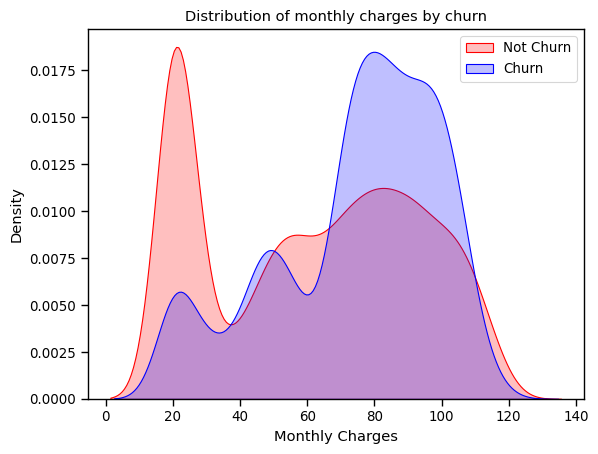

In [73]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');

월간 지불 요금이 높은 고객일 수록 이탈률이 급격히 증가하는 것을 확인

In [74]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

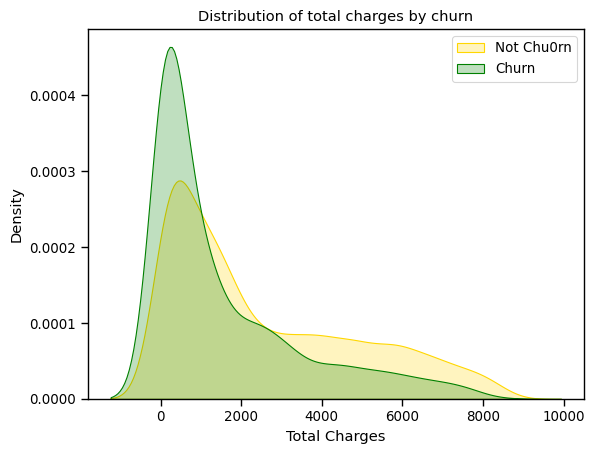

In [75]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", shade = True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", shade= True);
ax.legend(["Not Chu0rn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');

전체 지불 비용이 적을 수록 이탈률이 높지만, 위 그래프는 월간 지불 요금이 높을 수록 이탈률이 증가하는 것으로 보아, 신규 고객의 이탈 가능성을 확인해볼 필요가 있어보임.

In [76]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

이탈자의 대부분이 서비스 이용 기간이 길지 않은 사용자들로 구성되어 있음.

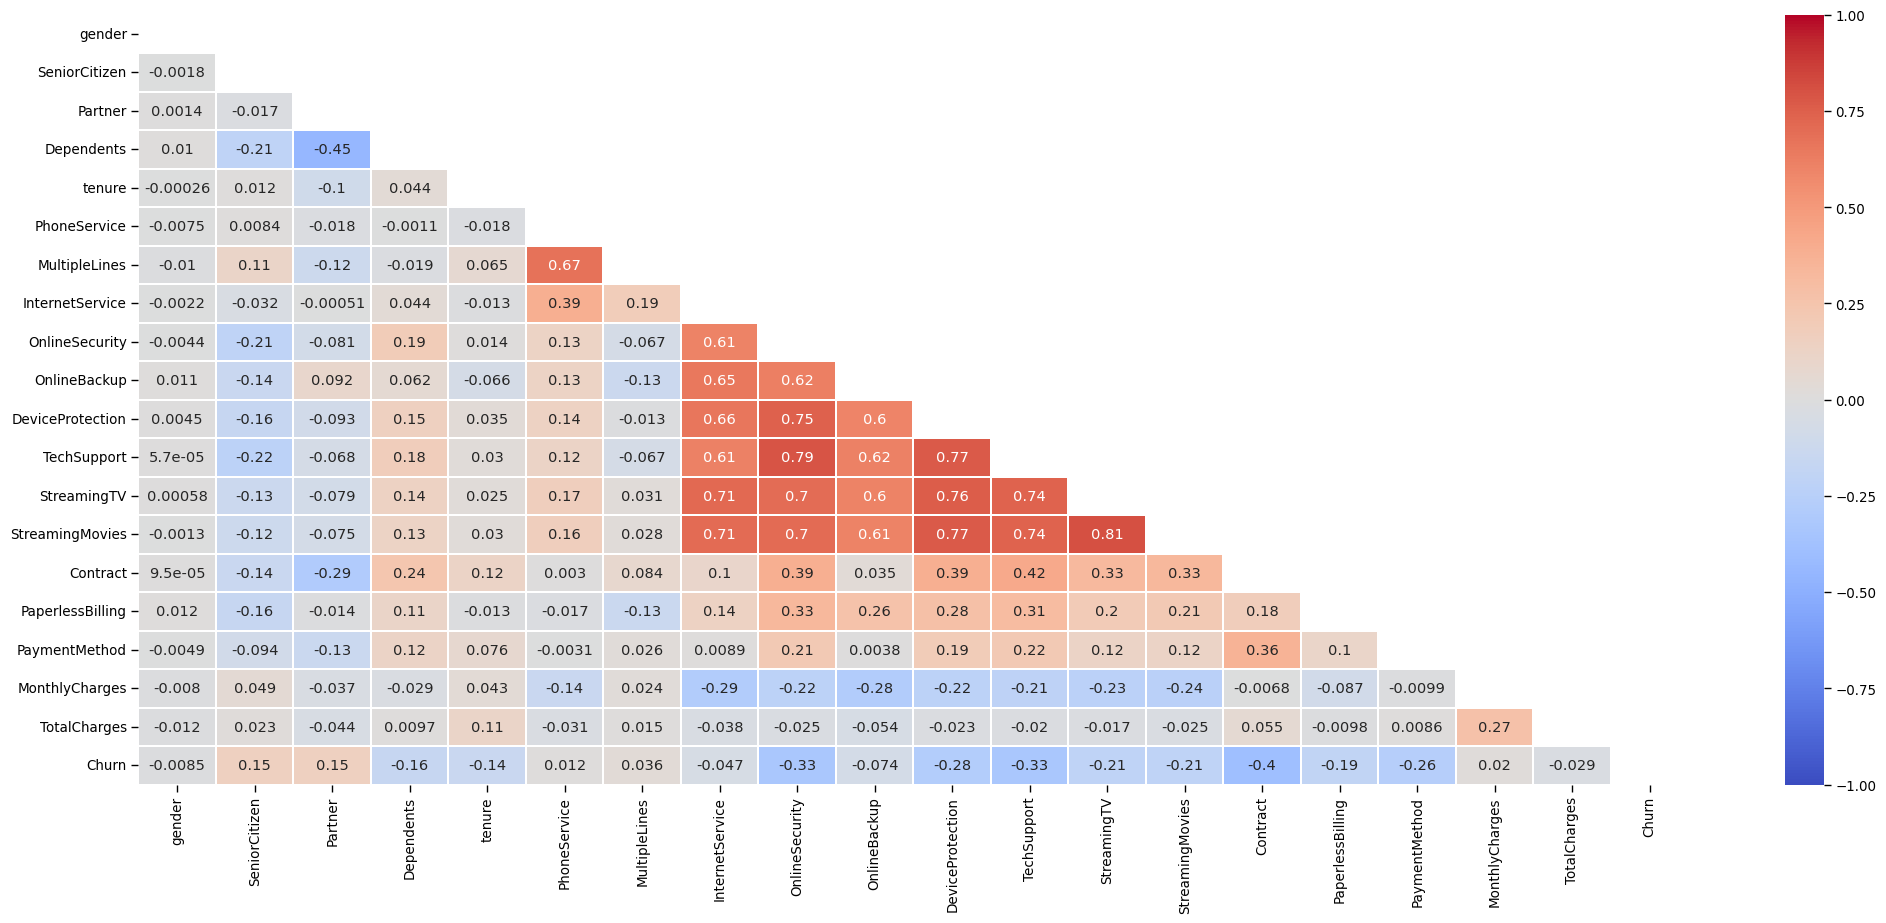

In [77]:
plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

### 데이터 시각화 요약
- 성별·부양가족 여부는 전체 분포와 큰 차이가 없어 이탈과의 직접 상관이 약한 반면, 파트너가 없고(Partner=No) 젊은 고객, 디지털 청구서 사용 고객에서 이탈 경향이 더 높게 나타남.
- 계약·결제 방식이 이탈을 강하게 좌우하며, 이탈 고객의 대부분이 월 단위 계약(≈88.6%)*이고 Electronic check(≈57.3%) 선택 비중이 가장 큼.
- 서비스/요금 특성에서도 차이가 뚜렷해 Fiber optic 가입자와 온라인 보안·기술지원 미사용 고객에서 이탈이 높고, 월 요금이 높을수록 이탈률이 급격히 증가함.

## 데이터 전처리

In [78]:
def object_to_int(dataframe_series):
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [79]:
df = df.apply(lambda x: object_to_int(x))
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


- gender male:female, (1,0)
- partner yes:no, (1,0)
- dependents yes:no, (1,0)
- phoneservice yes:no, (1,0)
- multiplelines yes:no, (1,0)
- internetservice DSL:Fiber optic:no internet, (0,1,2)
- onlinesecurity yes:no:no internet, (2,0,1)
- onlinebackup yes:no:no internet, (2,0,1)
- deviceprotection yes:no:no internet, (2,0,1)
- techsupport yes:no:no internet, (2,0,1)
- contract yes:no, (1,0)
- paperlessbilling yes:no, (1,0)
- paymentmethod electrronic check:mailed check:bank transfet:credit card (2,3,0,1)
- churn yes:no, (1,0)

In [80]:
plt.figure(figsize=(14,7))
df.corr()['Churn'].sort_values(ascending = False)

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

<Figure size 1400x700 with 0 Axes>

In [81]:
X = df.drop(columns = ['Churn'])
y = df['Churn'].values

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 2026, stratify=y)

In [83]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.distplot(frame[feature], color= color)

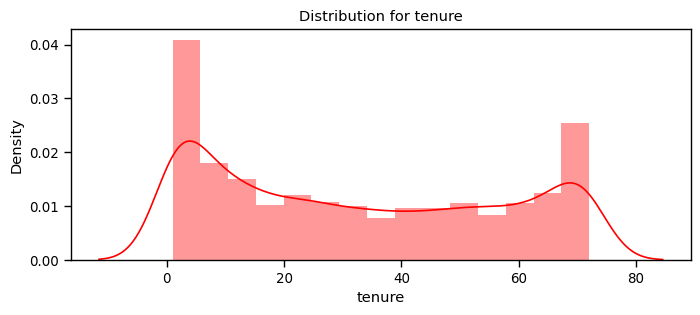

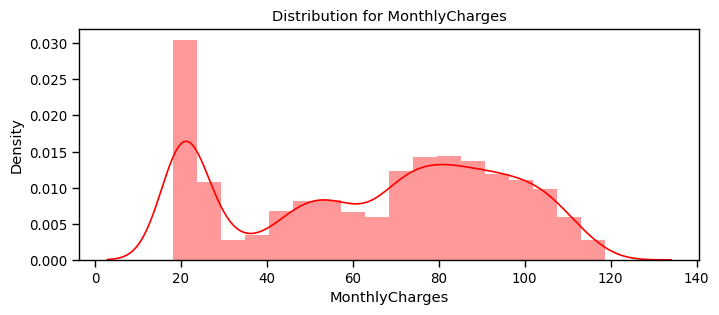

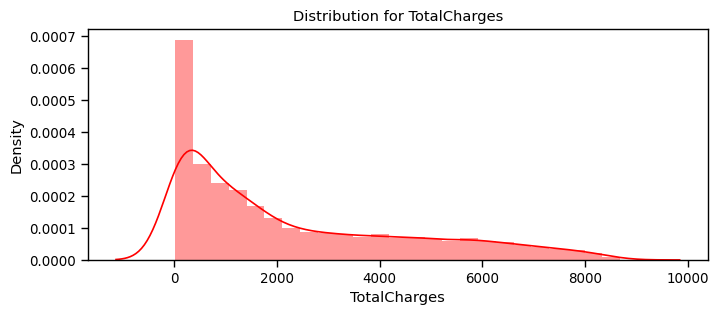

In [84]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

수치형 특성들의 범위가 달라 표준 스케일러를 사용할 필요가 있어보임.

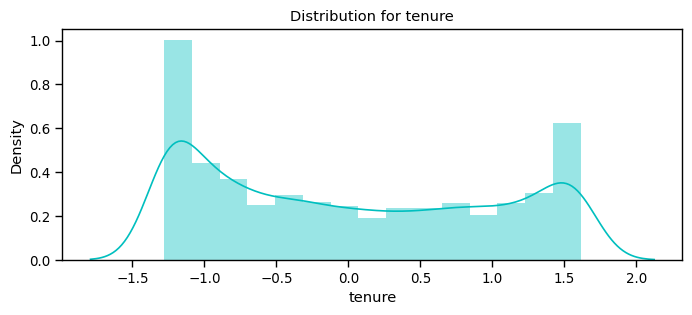

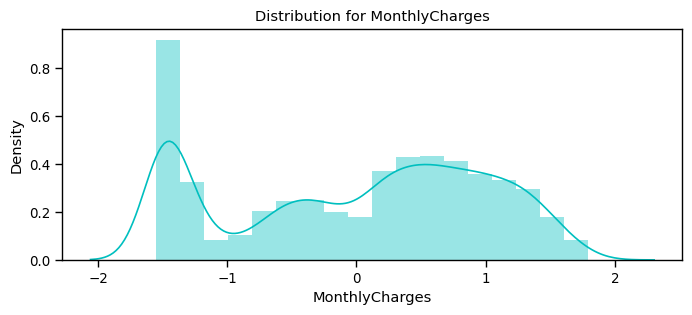

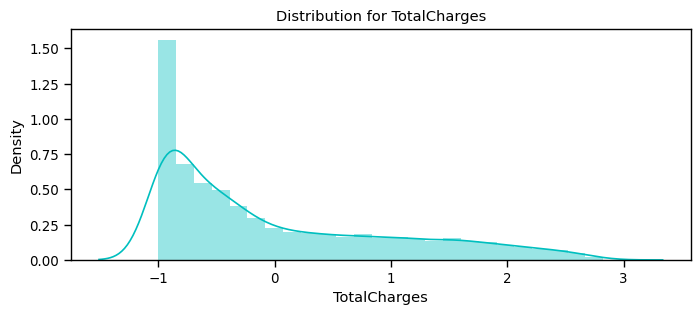

In [85]:
df_std = pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')),
                       columns=num_cols)
for feat in num_cols: distplot(feat, df_std, color='c')

In [86]:
# 컬럼들을 세 가지 카테고리로 분류합니다: 표준화(Standardization)를 위한 카테고리, 
# 라벨 인코딩(Label Encoding)을 위한 카테고리, 그리고 원-핫 인코딩(One-Hot Encoding)을 위한 카테고리입니다.
cat_cols_ohe =['PaymentMethod', 'Contract', 'InternetService'] # those that need one-hot encoding
cat_cols_le = list(set(X_train.columns)- set(num_cols) - set(cat_cols_ohe)) #those that need label encoding

In [87]:
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### 데이터 전처리 요약

## 머신러닝 모델 예측 및 평가

KNN

In [88]:
knn_model = KNeighborsClassifier(n_neighbors = 11) 
knn_model.fit(X_train,y_train)
predicted_y = knn_model.predict(X_test)
accuracy_knn = knn_model.score(X_test,y_test)
print("KNN accuracy:",accuracy_knn)

KNN accuracy: 0.7758293838862559


In [89]:
print(classification_report(y_test, predicted_y))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1549
           1       0.59      0.52      0.55       561

    accuracy                           0.78      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



SVC

In [90]:
svc_model = SVC(random_state = 2026)
svc_model.fit(X_train,y_train)
predict_y = svc_model.predict(X_test)
accuracy_svc = svc_model.score(X_test,y_test)
print("SVM accuracy is :",accuracy_svc)

SVM accuracy is : 0.8075829383886256


In [91]:
print(classification_report(y_test, predict_y))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1549
           1       0.69      0.50      0.58       561

    accuracy                           0.81      2110
   macro avg       0.76      0.71      0.73      2110
weighted avg       0.80      0.81      0.80      2110



Random Forest

In [92]:
model_rf = RandomForestClassifier(n_estimators=500 , oob_score = True, n_jobs = -1,
                                  random_state =50, max_features = "sqrt",
                                  max_leaf_nodes = 30)
model_rf.fit(X_train, y_train)

# Make predictions
prediction_test = model_rf.predict(X_test)
print (metrics.accuracy_score(y_test, prediction_test))

0.8137440758293839


In [93]:
print(classification_report(y_test, prediction_test))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1549
           1       0.71      0.51      0.59       561

    accuracy                           0.81      2110
   macro avg       0.77      0.72      0.74      2110
weighted avg       0.80      0.81      0.80      2110



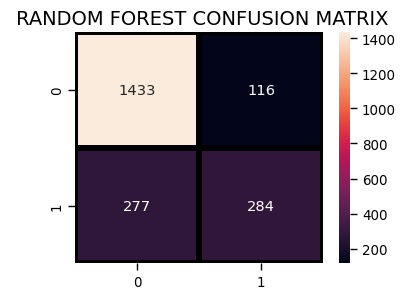

In [94]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, prediction_test),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title(" RANDOM FOREST CONFUSION MATRIX",fontsize=14)
plt.show()

- TN (실제 0, 예측 0) = 1433
→ 이탈하지 않은 고객을 “이탈 아님”으로 정확히 맞춤
- FP (실제 0, 예측 1) = 116
→ 이탈하지 않은 고객을 “이탈”로 오탐(False Alarm)
- FN (실제 1, 예측 0) = 277
→ 실제 이탈 고객을 “이탈 아님”으로 놓침(미탐)  ← 가장 치명적인 부분
- TP (실제 1, 예측 1) = 284
→ 이탈 고객을 “이탈”로 정확히 맞춤

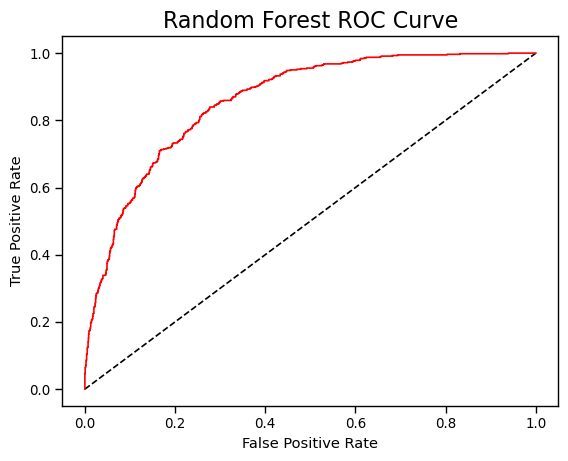

In [95]:
y_rfpred_prob = model_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_rfpred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_rf, tpr_rf, label='Random Forest',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve',fontsize=16)
plt.show();

Logistic Regression

In [96]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)
accuracy_lr = lr_model.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr)

Logistic Regression accuracy is : 0.8090047393364929


In [97]:
lr_pred= lr_model.predict(X_test)
report = classification_report(y_test,lr_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.58      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.74      0.75      2110
weighted avg       0.80      0.81      0.80      2110



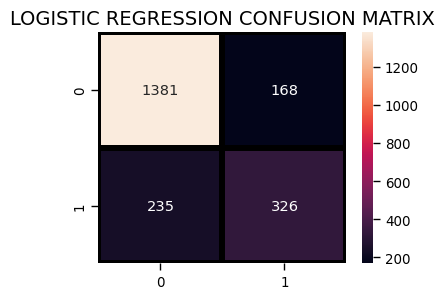

In [98]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",fontsize=14)
plt.show()

- TN (실제 0, 예측 0) = 1381
→ 비이탈 고객을 비이탈로 맞춤
- FP (실제 0, 예측 1) = 168
→ 비이탈인데 이탈로 잘못 예측(오탐)
- FN (실제 1, 예측 0) = 235
→ 실제 이탈인데 비이탈로 예측(미탐/놓침)
- TP (실제 1, 예측 1) = 326
→ 이탈 고객을 이탈로 맞춤

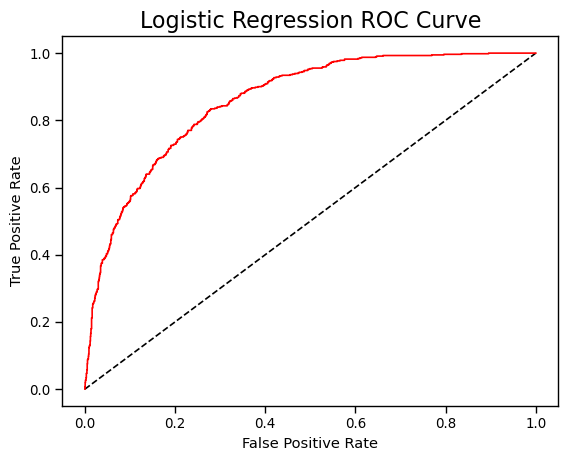

In [99]:
y_pred_prob = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve',fontsize=16)
plt.show();

Decision Tree Classifier

In [100]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
predictdt_y = dt_model.predict(X_test)
accuracy_dt = dt_model.score(X_test,y_test)
print("Decision Tree accuracy is :",accuracy_dt)

Decision Tree accuracy is : 0.7303317535545024


In [101]:
print(classification_report(y_test, predictdt_y))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1549
           1       0.49      0.53      0.51       561

    accuracy                           0.73      2110
   macro avg       0.66      0.67      0.66      2110
weighted avg       0.74      0.73      0.73      2110



AdaBoost Classifier

In [102]:
a_model = AdaBoostClassifier()
a_model.fit(X_train,y_train)
a_preds = a_model.predict(X_test)
print("AdaBoost Classifier accuracy")
metrics.accuracy_score(y_test, a_preds)

AdaBoost Classifier accuracy


0.8127962085308057

In [103]:
print(classification_report(y_test, a_preds))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.56      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.75      2110
weighted avg       0.81      0.81      0.81      2110



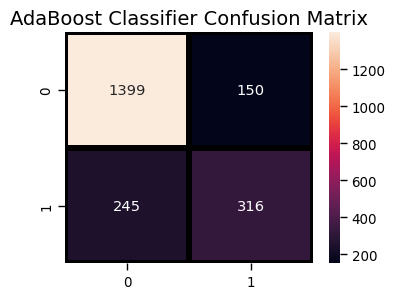

In [104]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, a_preds),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("AdaBoost Classifier Confusion Matrix",fontsize=14)
plt.show()

- TN (실제 0 → 예측 0) = 1399
→ 비이탈 고객을 비이탈로 맞춤
- FP (실제 0 → 예측 1) = 150
→ 비이탈인데 이탈로 잘못 예측(오탐)
- FN (실제 1 → 예측 0) = 245
→ 실제 이탈인데 비이탈로 예측(미탐/놓침)
- TP (실제 1 → 예측 1) = 316
→ 이탈 고객을 이탈로 맞춤

Gradient Boosting Classifier

In [105]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting Classifier", accuracy_score(y_test, gb_pred))

Gradient Boosting Classifier 0.8080568720379147


In [106]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1549
           1       0.67      0.55      0.60       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



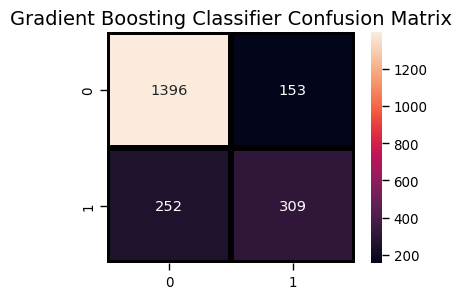

In [107]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, gb_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("Gradient Boosting Classifier Confusion Matrix",fontsize=14)
plt.show()

- TN (실제 0 → 예측 0) = 1396
→ 비이탈 고객을 비이탈로 맞춤
- FP (실제 0 → 예측 1) = 153
→ 비이탈인데 이탈로 잘못 예측(오탐)
- FN (실제 1 → 예측 0) = 252
→ 실제 이탈인데 비이탈로 예측(미탐/놓침)
- TP (실제 1 → 예측 1) = 309
→ 이탈 고객을 이탈로 맞춤

보팅 분류기 (Voting Classifier)
- 가장 높은 다수결 투표(Majority Voting)를 기반으로 최종 모델을 예측

이때 사용하는 모델을 gradient boosting, logistic regression, ada boost 모델만을 사용.
gradientboosting, adaboost는 둘다 부스팅 계열이지만
- AdaBoost는 놓친 이탈 고객을 계속 집중해서 잡아내려는 스타일(하지만 노이즈에 집착할 수 있음)
- Gradient Boosting은 전체 오차를 조금씩 줄여 복잡한 패턴을 정교하게 학습하는 스타일(하지만 소수 이탈을 더 잡으려면 조정이 필요할 수 있음)
달라서 차이가 있어 사용.
logisticregression은 선형 모델이라서 사용.

반대로, randomforest는 트리기반으로, 부스팅과 비슷해 확률 평균이 애매해 질 수 있어 제외.

svc모델은 확률이 추정치로 계산되므로 배제.
knn모델은 스케일에 따라 변동성이 크므로 배제.

In [108]:
from sklearn.ensemble import VotingClassifier
clf1 = GradientBoostingClassifier()
clf2 = LogisticRegression()
clf3 = AdaBoostClassifier()
eclf1 = VotingClassifier(estimators=[('gbc', clf1), ('lr', clf2), ('abc', clf3)], voting='soft')
eclf1.fit(X_train, y_train)
predictions = eclf1.predict(X_test)
print("Final Accuracy Score ")
print(accuracy_score(y_test, predictions))

Final Accuracy Score 
0.8161137440758294


In [109]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.57      0.62       561

    accuracy                           0.82      2110
   macro avg       0.77      0.74      0.75      2110
weighted avg       0.81      0.82      0.81      2110



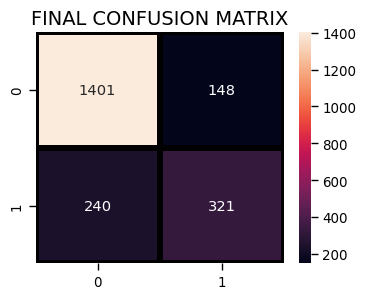

In [110]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predictions),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("FINAL CONFUSION MATRIX",fontsize=14)
plt.show()

- TN (실제 0 → 예측 0) = 1401
→ 비이탈 고객을 비이탈로 맞춤
- FP (실제 0 → 예측 1) = 148
→ 비이탈인데 이탈로 잘못 예측(오탐)
- FN (실제 1 → 예측 0) = 240
→ 실제 이탈인데 비이탈로 예측(미탐/놓침)
- TP (실제 1 → 예측 1) = 321
→ 이탈 고객을 이탈로 맞춤

In [120]:
r = permutation_importance(eclf1, X_test, y_test, n_repeats=10, random_state=2026, n_jobs=-1)
imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

print(imp.head(15))

Contract            0.089100
TechSupport         0.052180
OnlineSecurity      0.032796
DeviceProtection    0.019194
OnlineBackup        0.004076
Dependents          0.002417
PaperlessBilling    0.001896
StreamingMovies     0.000379
InternetService     0.000332
MonthlyCharges      0.000000
gender             -0.000190
Partner            -0.000900
SeniorCitizen      -0.001422
PhoneService       -0.001659
PaymentMethod      -0.002464
dtype: float64


In [118]:
y_pred = eclf1.predict(X_test)

test = X_test.copy()
test["y_true"] = y_test
test["y_pred"] = y_pred

# 실제 이탈자(1)만 골라서 범주형 분포 확인
churners = test[test["y_true"] == 1]

for col in X_test.columns:
    print("\n", col)
    print(churners[col].value_counts(normalize=True).mul(100).round(1))


 gender
gender
0    50.1
1    49.9
Name: proportion, dtype: float64

 SeniorCitizen
SeniorCitizen
0    74.5
1    25.5
Name: proportion, dtype: float64

 Partner
Partner
0    62.6
1    37.4
Name: proportion, dtype: float64

 Dependents
Dependents
0    82.4
1    17.6
Name: proportion, dtype: float64

 tenure
tenure
1     21.2
2      6.1
3      5.5
4      4.6
9      2.9
      ... 
63     0.2
45     0.2
58     0.2
64     0.2
55     0.2
Name: proportion, Length: 71, dtype: float64

 PhoneService
PhoneService
1    90.7
0     9.3
Name: proportion, dtype: float64

 MultipleLines
MultipleLines
2    47.2
0    43.5
1     9.3
Name: proportion, dtype: float64

 InternetService
InternetService
1    71.5
0    23.7
2     4.8
Name: proportion, dtype: float64

 OnlineSecurity
OnlineSecurity
0    79.9
2    15.3
1     4.8
Name: proportion, dtype: float64

 OnlineBackup
OnlineBackup
0    64.3
2    30.8
1     4.8
Name: proportion, dtype: float64

 DeviceProtection
DeviceProtection
0    64.5
2    30.7
1    